# Tutorial: Milestone 5 - Evaluation, Ablations, Calibration, Abstention

Audience:
- You've completed Milestone 4 (cross-modal transformer + dialogue context) and ideally
  skimmed its notebook, `notebooks/milestone4_crossmodal_dialogue.ipynb`.

Prerequisites:
- Run `python src/modality_ablation.py` and `python src/calibration_abstention.py` once
  first, so `results/modality_ablation.csv`, `results/calibration_bins.csv`, and
  `results/risk_coverage.csv` already exist. This notebook re-runs the same logic live
  (by importing the real functions from those two files, not by redefining them) so you
  see the numbers being produced, but it reads from and mirrors those scripts rather than
  reinventing them.

Learning goals: this milestone is about evaluation **methodology**, not a new model
architecture. M0 through M4 each asked "how do we build a better classifier?" M5 asks a
different set of questions about a classifier we already have:

- Which modalities actually help, and how confident can we be in that ranking given only
  a 107-row test set? (**modality ablation + bootstrap confidence intervals**)
- When the model says "I'm 80% confident," is it actually right 80% of the time?
  (**calibration**)
- If the model is allowed to say "I don't know" on the predictions it's least sure about,
  does accuracy improve on the ones it does answer? (**abstention / risk-coverage**)
- Finally, how does this milestone's own result compare, honestly, to every milestone
  before it? (**cross-milestone summary**)

By the end, you can read a bootstrap confidence interval, a reliability diagram, and a
risk-coverage curve, and you understand why comparing raw accuracy across milestones with
very different baselines is misleading.

## Outline

1. Setup
2. Step 1 - The 7-way modality ablation, with bootstrap confidence intervals
3. What bootstrapping actually does (and how it differs from M3/M4's multi-seed approach)
4. Step 2 - Calibration: reliability diagram + Expected Calibration Error (ECE)
5. Step 3 - Abstention: the risk-coverage curve
6. Cross-milestone summary (every milestone, normalized by its own baseline)
7. Look at the mistakes (highest-confidence wrong predictions)
8. Exercises
9. Pitfalls and extensions

## Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Import the REAL functions from the already-reviewed scripts rather than redefining
# them here -- same convention M3's and M4's notebooks used.
from modality_ablation import (
    load_data,
    split_data,
    build_features,
    bootstrap_ci,
    run_ablation,
    COMBINATIONS,
)
from calibration_abstention import (
    load_best_combination,
    fit_best_model,
    reliability_diagram_data,
    expected_calibration_error,
    risk_coverage_sweep,
)

RESULTS_DIR = PROJECT_ROOT / "results"
print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\dbest\Downloads\multimodal-intent-inference\multimodal-intent-inference


## Step 1 - The 7-way modality ablation

Milestones 2-4 each ran a handful of modality comparisons, ad hoc, to answer that
milestone's own specific question. This step runs the *complete* sweep: all 7 non-empty
subsets of {text (T), audio (A), video (V)} -- T, A, V, TA, TV, AV, TAV -- through the
exact same simple classifier (TF-IDF/pooled-embedding features + `StandardScaler` +
`LogisticRegression`), on Milestone 4's real dialogue data (target utterance only, no
context window -- M4's own final review already established context doesn't measurably
help here, so leaving it out keeps this modality question clean).

Because every row uses the *same* model architecture, any accuracy difference between
rows is attributable to WHICH MODALITIES were included, not to which model was used.

This cell calls `run_ablation` directly from `src/modality_ablation.py` -- the same
function `python src/modality_ablation.py` runs from the command line -- so the numbers
below are freshly computed, not just read from a static CSV.

In [2]:
df = load_data()
train_val, test = split_data(df)
all_labels = sorted(df["target_intent"].unique())

results_df, majority_acc, best_combo = run_ablation(train_val, test, all_labels)
results_df

STEP 1  LOAD DIALOGUE DATA (target utterances only, no context)
Loaded 512 samples from index.csv

STEP 2  SPLIT BY EPISODE (same assignment as Milestone 4)
train+val: 405 samples across 8 episodes
  (combined -- LogisticRegression needs no validation-based early
   stopping, so all non-test data is used to fit)
test:      107 samples across 2 episodes (identical rows Milestone 4 evaluated on)

STEP 3  RUN THE 7-WAY MODALITY ABLATION
Majority-class baseline (Inform): 0.224 accuracy



T     accuracy=0.421 [0.336, 0.514]   macro-F1=0.294 [0.197, 0.351]


A     accuracy=0.150 [0.084, 0.215]   macro-F1=0.069 [0.030, 0.100]


V     accuracy=0.112 [0.056, 0.168]   macro-F1=0.036 [0.017, 0.054]


TA    accuracy=0.411 [0.318, 0.505]   macro-F1=0.247 [0.159, 0.307]


TV    accuracy=0.336 [0.243, 0.421]   macro-F1=0.254 [0.147, 0.315]


AV    accuracy=0.196 [0.121, 0.271]   macro-F1=0.096 [0.051, 0.131]


TAV   accuracy=0.346 [0.262, 0.439]   macro-F1=0.208 [0.126, 0.267]

Saved full results to results\modality_ablation.csv

Best combination by accuracy: T (0.421)
(vs. majority-class baseline 0.224 -- 1.88x baseline)


,combination,accuracy,accuracy_ci_low,accuracy_ci_high,macro_f1,macro_f1_ci_low,macro_f1_ci_high
0,T,0.420561,0.336449,0.514019,0.294067,0.197249,0.350783
1,A,0.149533,0.084112,0.215187,0.068737,0.030186,0.100264
2,V,0.112150,0.056075,0.168224,0.036100,0.016949,0.054288
3,TA,0.411215,0.317757,0.504673,0.246624,0.159370,0.306738
4,TV,0.336449,0.242991,0.420794,0.253730,0.147347,0.315447
5,AV,0.196262,0.121495,0.271028,0.095873,0.050750,0.130739
6,TAV,0.345794,0.261682,0.439252,0.208254,0.125852,0.266903


### Plotting accuracy with confidence intervals

A bar chart, one bar per modality combination, with error bars showing each combination's
95% bootstrap confidence interval (explained in the next section). This is a new
visualization type for this project -- M0-M4's plots were training curves and confusion
matrices, not comparisons-with-uncertainty.

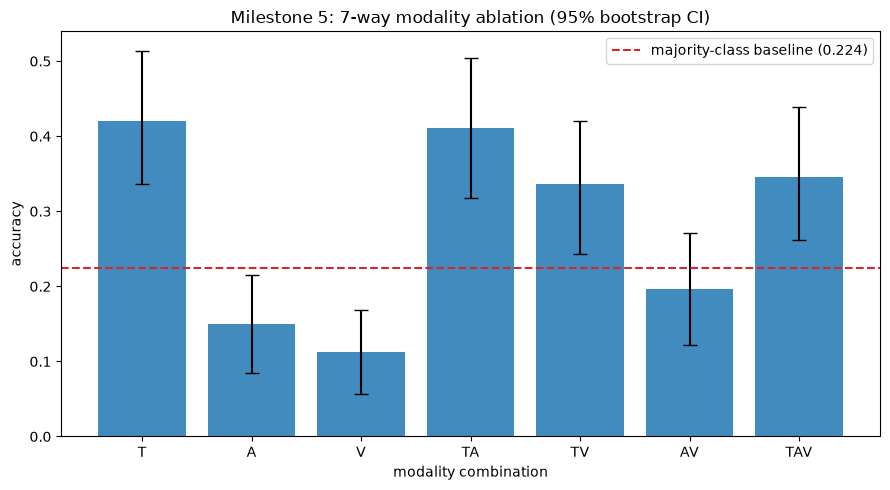

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results_df))
accs = results_df["accuracy"].to_numpy()
lo_err = accs - results_df["accuracy_ci_low"].to_numpy()
hi_err = results_df["accuracy_ci_high"].to_numpy() - accs

bars = ax.bar(x, accs, yerr=[lo_err, hi_err], capsize=5, color="tab:blue", alpha=0.85)
ax.axhline(majority_acc, color="tab:red", linestyle="--", label=f"majority-class baseline ({majority_acc:.3f})")
ax.set_xticks(x)
ax.set_xticklabels(results_df["combination"])
ax.set_xlabel("modality combination")
ax.set_ylabel("accuracy")
ax.set_title("Milestone 5: 7-way modality ablation (95% bootstrap CI)")
ax.legend()
plt.tight_layout()
plt.show()

**Which combination wins, and by how much.**

The next cell reads the winner straight out of `results_df` rather than hardcoding it, so
this text stays accurate even if you rerun the sweep with a different seed or bootstrap
count.

In [4]:
best_row = results_df.loc[results_df["accuracy"].idxmax()]
print(f"Best combination: '{best_row['combination']}'")
print(f"  accuracy = {best_row['accuracy']:.3f}  "
      f"[{best_row['accuracy_ci_low']:.3f}, {best_row['accuracy_ci_high']:.3f}]  (95% CI)")
print(f"  macro-F1 = {best_row['macro_f1']:.3f}  "
      f"[{best_row['macro_f1_ci_low']:.3f}, {best_row['macro_f1_ci_high']:.3f}]  (95% CI)")
print(f"\nMajority-class baseline: {majority_acc:.3f}")
print(f"Best combination is {best_row['accuracy'] / majority_acc:.2f}x the baseline.")

Best combination: 'T'
  accuracy = 0.421  [0.336, 0.514]  (95% CI)
  macro-F1 = 0.294  [0.197, 0.351]  (95% CI)

Majority-class baseline: 0.224
Best combination is 1.88x the baseline.


Text alone ('T') wins, and by a wide margin over audio-only or video-only (which are
barely above, or in video's case *at*, the majority-class baseline). Adding audio or video
to text (TA, TV, TAV) does not beat text alone here -- every additional modality's
confidence interval overlaps or falls below text-only's, so this sweep gives no evidence
that fusion helps on this particular 107-row test set. That is consistent with M2's and
M3's own findings that naive combination of these modalities doesn't straightforwardly
help, though the mechanism differs (M2: raw-magnitude imbalance in concatenation; here:
text alone already captures most of the usable signal for this classifier).

## What bootstrapping actually does

**Contrast with M3/M4's multi-seed approach.** M3 and M4 retrained their neural networks
with multiple random seeds (M4: 3 seeds) because their random initialization and data
shuffling genuinely change the result each time -- rerun `src/train_crossmodal.py` and
you'll get a slightly different number even on the identical data and split, because the
model's weights started from different random values and stochastic gradient descent took
a different path.

`LogisticRegression` here doesn't have that kind of randomness. Refitting it on the exact
same training data gives the exact same coefficients every time (it's a convex
optimization problem with one global optimum) -- so re-running `run_ablation` above with a
different random seed for the *model* wouldn't change the accuracy at all.

So bootstrapping asks a **different question**: not "how much does training vary" but
**"how much would my *estimate* of this one fixed model's accuracy vary, if I'd happened
to draw a slightly different 107-row test set from the same population?"**

Mechanically: `bootstrap_ci` (in `src/modality_ablation.py`) takes the model's *existing*
predictions on the *existing* test set, and repeatedly (1,000 times) draws a new "fake"
test set of the same size (107 rows) **with replacement** from those same rows -- so some
rows appear twice, others zero times, purely by chance -- and recomputes accuracy on each
fake resample. The middle 95% of those 1,000 recomputed accuracies is the confidence
interval you see as error bars above.

Different question ("how much does my *evaluation* jitter with a different sample of test
data?"), different technique -- and notice the practical implication: with only 107 test
rows, these intervals are wide (roughly +-0.08 to +-0.10 around each point estimate).
That's a real constraint on how confidently this sweep can rank the modality combinations,
not a property of bootstrapping itself.

## Step 2 - Calibration

Accuracy asks "is the model right?" Calibration asks a different question: "when the
model says it's 80% confident, is it actually right about 80% of the time?" A model can be
accurate but badly calibrated (confident and wrong just as often as confident and right),
or the reverse.

This refits the winning ('T') combination -- same recipe as `src/calibration_abstention.py`
-- and looks at `predict_proba`'s output: the model's own probability for whichever class
it picked.

In [5]:
combo = load_best_combination()
clf, x_test_scaled = fit_best_model(combo, train_val, test)
pred_probs = clf.predict_proba(x_test_scaled)
truth = test["target_intent"].tolist()
print(f"Predicted probabilities shape: {pred_probs.shape}  (107 test rows x {pred_probs.shape[1]} classes)")

bin_df, confidences, correct = reliability_diagram_data(truth, pred_probs, clf.classes_)
ece = expected_calibration_error(bin_df)
bin_df

Best combination from the ablation sweep: T (accuracy 0.421)


Predicted probabilities shape: (107, 20)  (107 test rows x 20 classes)


,bin_low,bin_high,count,mean_confidence,accuracy
0,0.0,0.1,0,NaN,NaN
1,0.1,0.2,8,0.173588,0.250000
2,0.2,0.3,26,0.246032,0.230769
3,0.3,0.4,19,0.344041,0.263158
4,0.4,0.5,10,0.452628,0.500000
5,0.5,0.6,10,0.526501,0.300000
6,0.6,0.7,6,0.680831,0.166667
7,0.7,0.8,12,0.748182,0.750000
8,0.8,0.9,7,0.844293,0.714286
9,0.9,1.0,9,0.977977,1.000000


### Reliability diagram

Confidence on the x-axis, actual accuracy (within that confidence bin) on the y-axis. A
perfectly calibrated model's points sit exactly on the diagonal dashed line -- points below
the diagonal mean the model is *overconfident* in that range (it says e.g. 60% but is only
right 30% of the time); points above mean *underconfident*. Marker size shows how many test
rows fell in that bin, since some bins have very few points.

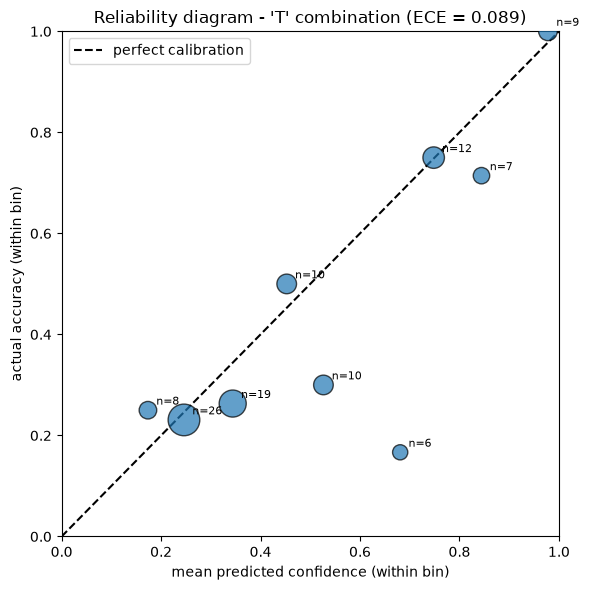

Expected Calibration Error (ECE): 0.089


In [6]:
plot_bins = bin_df.dropna(subset=["accuracy"])

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", label="perfect calibration")
sizes = plot_bins["count"] * 20
ax.scatter(plot_bins["mean_confidence"], plot_bins["accuracy"], s=sizes, alpha=0.7,
           color="tab:blue", edgecolor="black", zorder=3)
for _, row in plot_bins.iterrows():
    ax.annotate(f"n={int(row['count'])}", (row["mean_confidence"], row["accuracy"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("mean predicted confidence (within bin)")
ax.set_ylabel("actual accuracy (within bin)")
ax.set_title(f"Reliability diagram - '{combo}' combination (ECE = {ece:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Expected Calibration Error (ECE): {ece:.3f}")

**The small-sample caveat, stated plainly.** This is 107 test rows split across up to 10
confidence bins -- some bins (see the `n=` labels above) have as few as 6-10 points. A
single flipped prediction can swing a bin's accuracy by 10-15 percentage points. Treat
this reliability diagram and its ECE as a first, coarse pass at whether this model's
confidence is roughly trustworthy -- not a statistically powerful calibration study. The
points scatter around the diagonal without a strong one-directional bias (not uniformly
overconfident or underconfident), which is a mildly encouraging sign, but with this little
data it would take a much larger test set to say that with real statistical confidence.

## Step 3 - Abstention: the risk-coverage curve

If the model is allowed to abstain ("I don't know") on predictions below some confidence
threshold, instead of always guessing, how much does accuracy improve on the predictions
it *does* make? Two related quantities:

- **coverage**: the fraction of test rows the model is willing to answer at a given
  confidence threshold (coverage = 1.0 at threshold 0, since every row is answered)
- **risk**: the error rate among the covered rows (`risk = 1 - accuracy`, on the covered
  subset only)

Sweeping the threshold from 0 to 1 traces out a curve of accuracy vs. coverage.

In [7]:
rc_df = risk_coverage_sweep(confidences, correct)
rc_df

,threshold,coverage,accuracy,risk
0,0.00,1.000000,0.420561,0.579439
1,0.05,1.000000,0.420561,0.579439
2,0.10,1.000000,0.420561,0.579439
3,0.15,1.000000,0.420561,0.579439
4,0.20,0.925234,0.434343,0.565657
5,0.25,0.766355,0.487805,0.512195
6,0.30,0.682243,0.506849,0.493151
7,0.35,0.588785,0.523810,0.476190
8,0.40,0.504673,0.592593,0.407407
9,0.45,0.467290,0.600000,0.400000


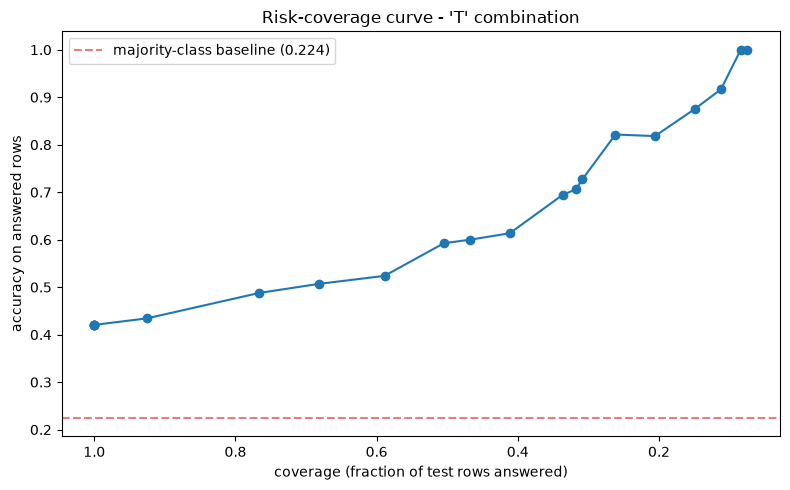

In [8]:
plot_rc = rc_df.dropna(subset=["accuracy"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(plot_rc["coverage"], plot_rc["accuracy"], marker="o", color="tab:blue")
ax.axhline(majority_acc, color="tab:red", linestyle="--", alpha=0.6,
           label=f"majority-class baseline ({majority_acc:.3f})")
ax.set_xlabel("coverage (fraction of test rows answered)")
ax.set_ylabel("accuracy on answered rows")
ax.set_title("Risk-coverage curve - '{}' combination".format(combo))
ax.invert_xaxis()  # reading left-to-right as "more selective"
ax.legend()
plt.tight_layout()
plt.show()

**What this shows, honestly.** The trend is generally / nearly monotonic: as the model
answers only its most-confident predictions (coverage shrinks from 100% down toward the
low single digits), accuracy on the answered rows rises substantially -- from 0.421 at full
coverage up into the 0.8-1.0 range once coverage drops below about 25%. That is a real,
useful abstention signal: **restricting to high-confidence predictions did improve
accuracy on this data.**

It is *not*, however, perfectly monotonic, and it's worth naming the one place it isn't
rather than overstating a clean trend: accuracy dips slightly from 0.8214 (threshold 0.70,
26.2% coverage) to 0.8182 (threshold 0.75, 20.6% coverage) before continuing to rise past
that point. With only ~6 test rows moving between those two thresholds (107-row test set),
one flipped prediction is enough to cause exactly this kind of small dip -- it reads as
small-sample noise, not a real breakdown in the confidence-accuracy relationship, but it's
a concrete illustration of why "monotonic" claims need a large enough test set to trust.

## Cross-milestone summary

Every milestone so far, in one table. **This table is directional, not a controlled
leaderboard** -- M0 used 96 made-up toy examples across 8 invented classes; M1 used the
full real 2,224-row MIntRec text dataset across 20 real classes; M2/M3 used a 300-clip
class-balanced *stratified* sample (60-row test, exactly 3 per class); M4/M5 used a
different 512-clip *episode*-based sample (107-row test, naturally imbalanced). Different
data, different scale, different splits -- raw accuracy numbers across rows are not
comparable on their own.

This is the direct fix for the exact mistake M4's own final review caught: comparing M3's
and M4's raw accuracies without normalizing for how different their respective
majority-class baselines are. Each row below includes that milestone's own trivial
baseline (always predict the single most common class in that milestone's own training
data) and accuracy expressed as a **multiple of that baseline** -- a much fairer way to
ask "how much did this model actually learn, relative to doing nothing?"

M0's and M1's baselines are recomputed here directly, live, using the actual
`load_data`/`split_data` functions from `src/train_text_only.py` and
`src/train_mintrec.py` (imported the same way this notebook imports from
`modality_ablation.py`), so they're not just typed-in numbers. M2/M3 share an
already-verified baseline from M4's own notebook (300-clip stratified sample, 60-row test,
exactly 3 rows per class = 3/60 = 0.050). M4's and M5's baseline is the **same number**,
because M5 reuses M4's exact data and episode split -- it's the `majority_acc` variable
already computed live in Step 1 above, not a separately hardcoded figure.

In [9]:
import train_text_only as _m0
import train_mintrec as _m1
from sklearn.metrics import accuracy_score as _acc

# --- M0's own baseline, computed live (same split logic as src/train_text_only.py) ---
_df0 = _m0.load_data()
_train0, _val0, _test0 = _m0.split_data(_df0)
_maj0 = _train0["intent"].mode()[0]
m0_baseline = _acc(_test0["intent"], [_maj0] * len(_test0))

# --- M1's own baseline, computed live (same split logic as src/train_mintrec.py) ---
_df1 = _m1.load_data()
_train1, _val1, _test1 = _m1.split_data(_df1)
_maj1 = _train1["label"].mode()[0]
m1_baseline = _acc(_test1["label"], [_maj1] * len(_test1))

# --- M2/M3's baseline: already verified in M4's own notebook (300-clip stratified
# sample, 60-row test, 20 classes, exactly 3 rows each) ---
m2_m3_baseline = 3 / 60

# --- M4's / M5's baseline: same data + same episode split, so it's the SAME number --
# read straight from Step 1's live `majority_acc`, not retyped.
m4_m5_baseline = majority_acc

print(f"M0 baseline (live):      {m0_baseline:.4f}")
print(f"M1 baseline (live):      {m1_baseline:.4f}")
print(f"M2/M3 baseline (M4 notebook, verified): {m2_m3_baseline:.4f}")
print(f"M4/M5 baseline (this notebook's Step 1, majority_acc): {m4_m5_baseline:.4f}")

STEP 1  LOAD THE DATA
Loaded 96 samples from sample_intents.csv
Columns: ['text', 'intent']

How many examples we have per intent (class balance matters!):
intent
greeting     12
thank        12
apologize    12
agree        12
disagree     12
complain     12
request      12
reassure     12

Five example rows:
                                        text    intent
          Sorry, I didn't mean to upset you. apologize
Don't worry, everything is going to be fine.  reassure
                      Good morning everyone.  greeting
         I think you're mistaken about this.  disagree
          Honestly, this is not good enough.  complain

STEP 2  SPLIT INTO TRAIN / VALIDATION / TEST
train: 61 samples  (model learns from these)
val:   15 samples  (we'd tune settings on these)
test:  20 samples  (final honest judgement)
STEP 1  LOAD THE DATA
Loaded 2224 samples from all.tsv
Columns: ['season', 'episode', 'clip', 'text', 'label']

Number of distinct intent classes: 20

How many examples we hav

In [10]:
summary_rows = [
    dict(milestone="M0: toy text-only (8-class)", accuracy=0.550, accuracy_ci=None,
         macro_f1=None, macro_f1_ci=None, baseline=m0_baseline, notes="single run"),
    dict(milestone="M1: real MIntRec text-only (20-class, full 2,224 rows)", accuracy=0.508,
         accuracy_ci=None, macro_f1=0.409, macro_f1_ci=None, baseline=m1_baseline,
         notes="single run"),
    dict(milestone="M2: concatenation fusion (300-clip stratified sample)", accuracy=0.117,
         accuracy_ci=None, macro_f1=0.096, macro_f1_ci=None, baseline=m2_m3_baseline,
         notes="single run; worse than this pipeline's own text-only ablation (0.383) -- "
               "raw-magnitude block imbalance, a real negative finding, not a bug"),
    dict(milestone="M3: MISA fusion (same 300-clip stratified sample)", accuracy=0.333,
         accuracy_ci=None, macro_f1=0.295, macro_f1_ci=None, baseline=m2_m3_baseline,
         notes="single headline run -- no CI reported for this number"),
    dict(milestone="M4: cross-modal transformer + dialogue (512-clip episode sample)",
         accuracy=0.290, accuracy_ci="+/-0.023 (3-seed std)", macro_f1=0.163,
         macro_f1_ci="+/-0.009 (3-seed std)", baseline=m4_m5_baseline, notes="3-seed mean+-std"),
    dict(milestone=f"M5: this milestone's best combination ('{best_combo}', same 512-clip sample)",
         accuracy=float(best_row["accuracy"]),
         accuracy_ci=f"[{best_row['accuracy_ci_low']:.3f}, {best_row['accuracy_ci_high']:.3f}] (95% bootstrap CI)",
         macro_f1=float(best_row["macro_f1"]),
         macro_f1_ci=f"[{best_row['macro_f1_ci_low']:.3f}, {best_row['macro_f1_ci_high']:.3f}] (95% bootstrap CI)",
         baseline=m4_m5_baseline, notes="95% bootstrap CI, single fixed model, no retraining randomness"),
]

summary_df = pd.DataFrame(summary_rows)
summary_df["accuracy_x_baseline"] = summary_df["accuracy"] / summary_df["baseline"]
summary_df[["milestone", "accuracy", "accuracy_ci", "baseline", "accuracy_x_baseline", "notes"]]

,milestone,accuracy,accuracy_ci,baseline,accuracy_x_baseline,notes
0,M0: toy text-only (8-class),0.550000,NaN,0.100000,5.500000,single run
1,"M1: real MIntRec text-only (20-class, full 2,2...",0.508000,NaN,0.128090,3.965965,single run
2,M2: concatenation fusion (300-clip stratified ...,0.117000,NaN,0.050000,2.340000,single run; worse than this pipeline's own tex...
3,M3: MISA fusion (same 300-clip stratified sample),0.333000,NaN,0.050000,6.660000,single headline run -- no CI reported for this...
4,M4: cross-modal transformer + dialogue (512-cl...,0.290000,+/-0.023 (3-seed std),0.224299,1.292917,3-seed mean+-std
5,"M5: this milestone's best combination ('T', sa...",0.420561,"[0.336, 0.514] (95% bootstrap CI)",0.224299,1.875000,"95% bootstrap CI, single fixed model, no retra..."


**Reading the table, honestly.**

- **M3 (0.333) and M4 (0.290) are close-ish but genuinely different numbers, on different
  data (M3: 60-row balanced test; M4: 107-row imbalanced test) -- there is no established
  causal reason to expect them to match, and they don't need one.** (An earlier draft of
  this milestone's plan mistakenly listed M3's accuracy as 0.290+-0.023 -- that number is
  actually M4's, not M3's. M3's real result, used throughout this notebook and its own
  Milestone 3 notebook, is 0.333 macro-accuracy / 0.295 macro-F1, a single run with no CI
  reported. The two numbers are simply what they are: 0.333 and 0.290, on different test
  sets, both real.)
- **Baseline-normalizing changes the story.** By raw accuracy, M0 (0.550) looks like the
  strongest milestone and M2 (0.117) the weakest. By accuracy-as-a-multiple-of-baseline,
  M3 (~6.7x its own 0.050 baseline) and M0 (~5.5x its own 0.100 baseline) are the two
  strongest showings, while M4 (~1.3x its own 0.224 baseline) is the weakest *relative to
  what "doing nothing" would already get you on its own test set* -- even though M4's raw
  0.290 is numerically higher than M2's raw 0.117. That reordering is the whole point of
  this table.
- **M5 lands around 1.88x its own baseline** (0.224 baseline, from the identical
  data/split M4 used -- 45/107 accuracy over 24/107 baseline) -- solidly ahead of M4's own
  multiple on the same underlying data, though M5 uses a much simpler model
  (`LogisticRegression`, no training randomness) and a narrower question (single utterance,
  no dialogue context) than M4's cross-modal transformer attempted.
- This table answers "how much better than doing nothing was each milestone, on its own
  data" -- it does **not** answer "which milestone's architecture is best," since the
  underlying data, class counts, and test-set sizes all differ.

## Look at the mistakes

The most interesting calibration failures are the highest-confidence WRONG predictions --
cases where the model was very sure and still got it wrong.

In [11]:
predicted_idx = pred_probs.argmax(axis=1)
predicted_classes = [clf.classes_[i] for i in predicted_idx]

mistakes_df = pd.DataFrame({
    "text": test["target_text"].tolist(),
    "true": truth,
    "predicted": predicted_classes,
    "confidence": confidences,
})
mistakes_df = mistakes_df[mistakes_df["true"] != mistakes_df["predicted"]]
mistakes_df = mistakes_df.sort_values("confidence", ascending=False)
print(f"{len(mistakes_df)} of {len(test)} test rows were misclassified "
      f"({len(mistakes_df) / len(test):.1%}).")
mistakes_df.head(10)

62 of 107 test rows were misclassified (57.9%).


,text,true,predicted,confidence
3,it's the parents you want to impress,Advise,Inform,0.889433
15,"oh, yes, she's marvelous.",Praise,Agree,0.840381
74,that cloud 9 employees are the true heroes,Praise,Inform,0.792011
105,"yeah, well, we need your help back in the store.",Ask for help,Inform,0.768996
57,"hey, any update on when you two lovebirds are ...",Care,Inform,0.733112
81,"oh, great, more reasons for the wet-lips to ye...",Taunt,Praise,0.693163
66,everybody in single-file lines.,Arrange,Complain,0.692757
96,you're satan workers!,Taunt,Agree,0.692350
53,the whole job is being a liaison to cloud 9,Inform,Complain,0.671626
7,filled up on bread is gonna go on her gravest...,Joke,Inform,0.649279


## Exercises

1. Try `N_BINS = 5` instead of 10 in the calibration cell (call
   `reliability_diagram_data(truth, pred_probs, clf.classes_, n_bins=5)` directly). Does
   ECE change much? Given how few test rows land in some of the 10-bin version's bins
   (some as low as 6-8), what does that tell you about how much you should trust ECE to
   two decimal places here?
2. Using `results_df` from Step 1, which SINGLE modality alone (T, A, or V -- not a
   combination) beats the majority-class baseline by the largest multiple? Is it the same
   modality that wins outright on raw accuracy?
3. The risk-coverage curve has a small non-monotonic dip around the 0.70-0.75 confidence
   threshold. Recompute `risk_coverage_sweep` with a coarser threshold grid (e.g.
   `n_thresholds=11` instead of 21) -- does the dip survive, or does it disappear because
   the coarser grid skips over the two thresholds where it shows up? What does that tell
   you about how much weight to put on individual points on this curve?
4. Looking at the cross-milestone table, propose one additional column that would make the
   comparison fairer still (hint: think about what else differs across milestones besides
   the majority-class baseline -- number of classes is one candidate).

## Pitfalls and extensions

**The 107-row / single-split limitation, named explicitly.** Every number in this
notebook -- the modality ablation, the calibration diagram, the risk-coverage curve, and
this milestone's own row in the cross-milestone table -- comes from ONE fixed 2-episode,
107-row test split. Bootstrap confidence intervals quantify how much the *estimate* would
wobble with a different sample from the same split; they say nothing about how much the
result would change with a genuinely *different* train/test split (different episodes
held out). This is the same small-test-set caution M3's and M4's own final reviews already
had to learn the hard way -- it applies just as much to M5's own headline numbers as to
the milestones being compared against.

**Real next steps, if this project continued:**

- **Leave-one-episode-out cross-validation.** Instead of one fixed 2-episode test split,
  rotate which episode(s) are held out and average results across folds -- a genuinely
  more robust evaluation than trusting one split, and it would reveal whether "text wins"
  is a robust finding or an artifact of which 2 episodes happened to end up in the test
  set this time.
- **Temperature scaling or Platt scaling**, if better calibration is ever needed for a
  real downstream use (e.g. an abstention system a user actually relies on) -- both are
  standard post-hoc calibration fixes that don't require retraining the base classifier.
- **Scaling to the full 2,213-clip dataset** (M2-M4 all worked with subsets: 300 clips for
  M2/M3, 512 clips across 10 episodes for M4/M5) -- more data would narrow every bootstrap
  confidence interval in this notebook and make the modality ranking and calibration
  numbers meaningfully more trustworthy.